In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

df = pd.read_csv('2018.csv')

df['starttime'] = pd.to_datetime(df['starttime'])
df['stoptime'] = pd.to_datetime(df['stoptime'])

df['date'] = df['starttime'].dt.date
df['hour'] = df['starttime'].dt.hour
df['day_of_week'] = df['starttime'].dt.day_name()

current_year = df['starttime'].dt.year.mode()[0]
df['age'] = current_year - df['birth year']
df = df[(df['age'] >= 16) & (df['age'] < 100)]

# Dystans (km) w linii prostej
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


df['distance_km'] = haversine(
    df['start station longitude'], df['start station latitude'],
    df['end station longitude'], df['end station latitude']
)

df_valid = df[(df['distance_km'] > 0) & (df['tripduration'] > 60)].copy()

df_valid['speed_kmh'] = df_valid['distance_km'] / (df_valid['tripduration'] / 3600)
df_valid = df_valid[df_valid['speed_kmh'] < 45]

In [46]:
# Wiek a średnia prędkość jazdy

analiza_wynikowa = (
    df_valid
    .groupby(['gender', pd.cut(df_valid['age'], bins=[16, 25, 35, 45, 55, 65, 100])], observed=False)
    .agg(
        srednia_predkosc=('speed_kmh', 'mean'),
        mediana_czasu_przejazdu=('tripduration', 'median'),
        liczba_przejazdow=('bikeid', 'count')
    )
    .reset_index()
)

analiza_wynikowa = analiza_wynikowa[analiza_wynikowa['liczba_przejazdow'] > 0]
analiza_wynikowa.columns = [
    'Płeć', 'Grupa wiekowa',
    'Średnia prędkość (km/h)', 'Mediana czasu przejazdu (s)', 'Liczba przejazdów'
]

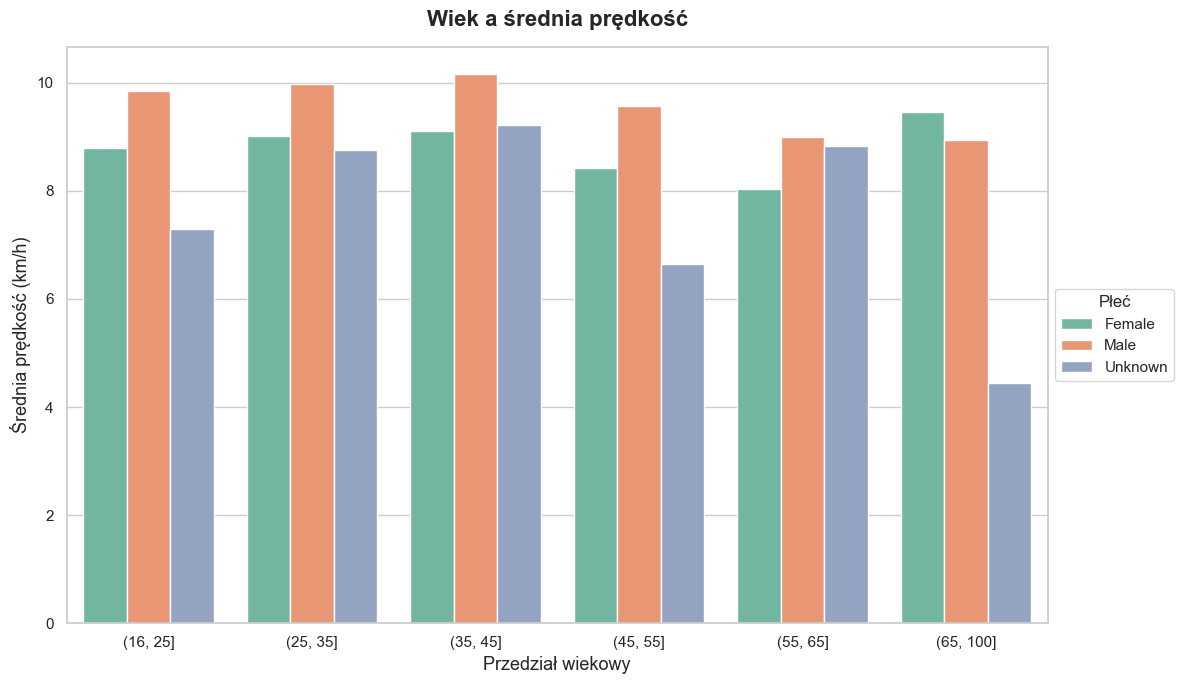

In [47]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=analiza_wynikowa,
    x='Grupa wiekowa',
    y='Średnia prędkość (km/h)',
    hue='Płeć',
    palette='Set2'
)

plt.title('Wiek a średnia prędkość', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Przedział wiekowy', fontsize=13)
plt.ylabel('Średnia prędkość (km/h)', fontsize=13)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), title='Płeć')

plt.savefig('V.png', dpi=300)
plt.show()

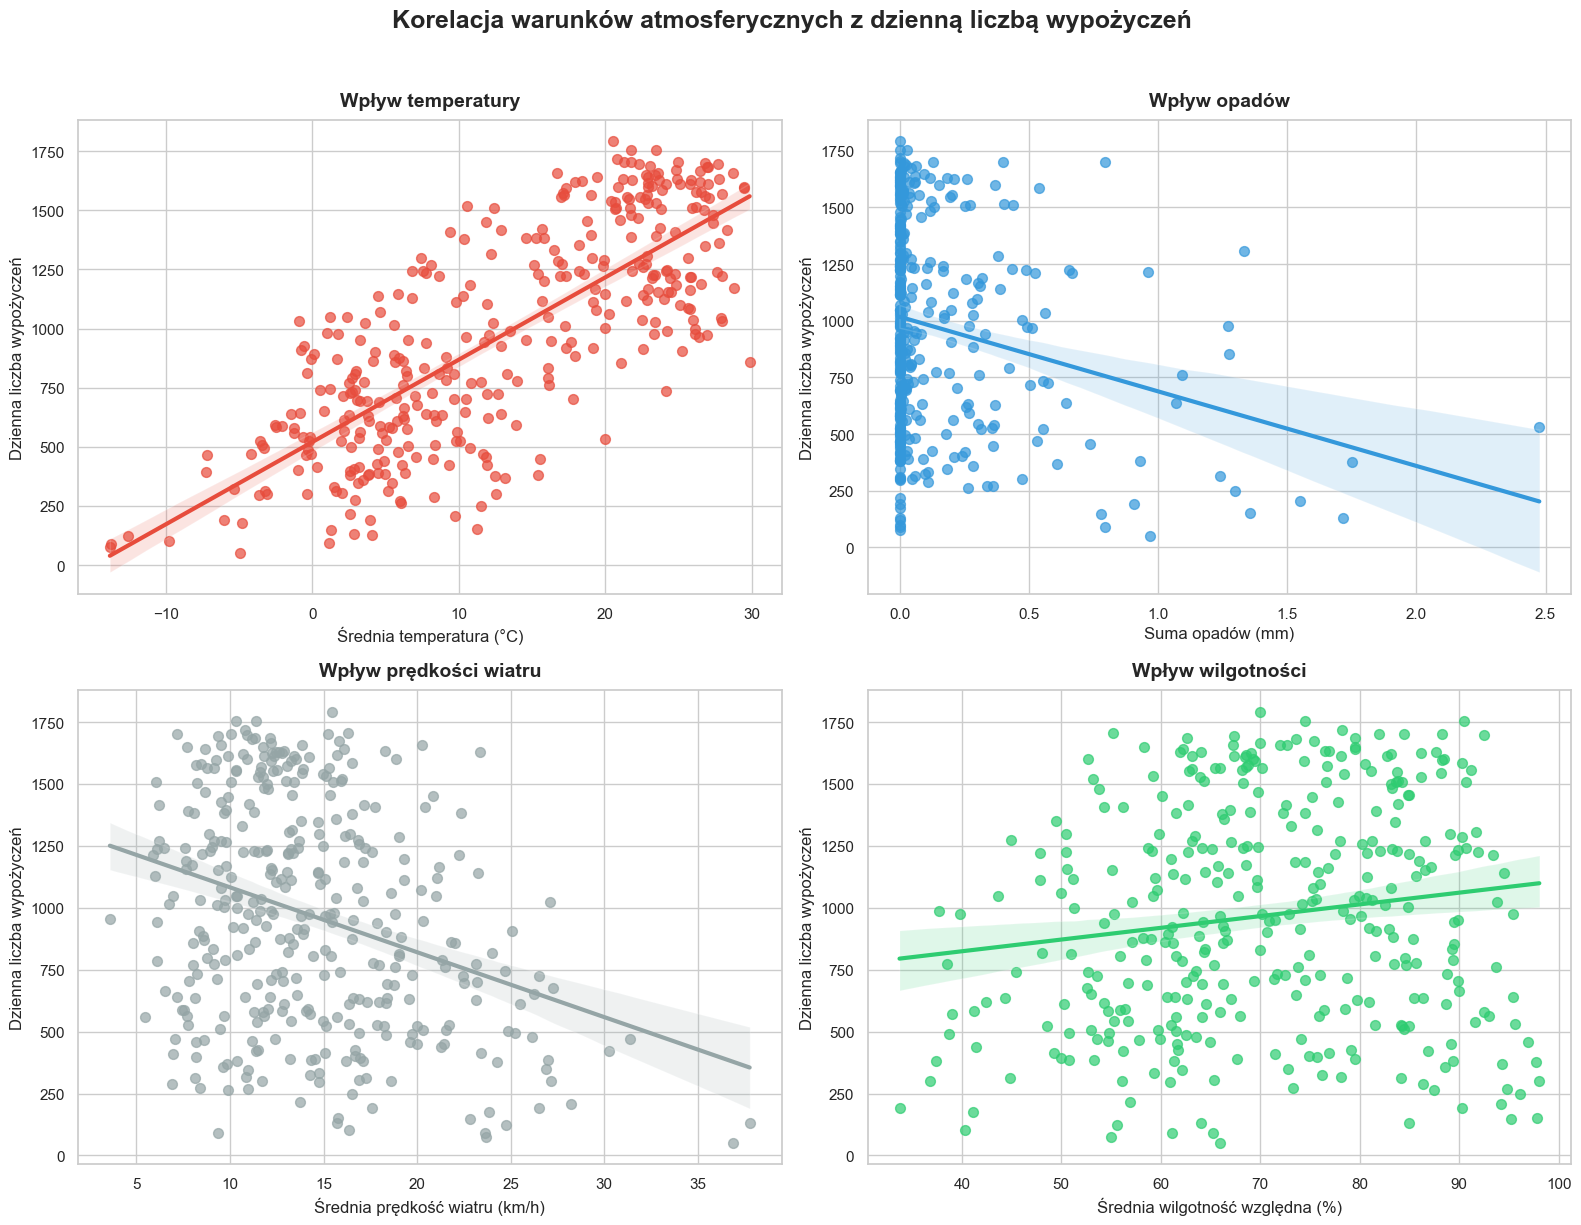

In [44]:
# Korelacja pogody z dzienną liczbą wypożyczeń

dzienna_aktywnosc = df.groupby('date').agg(
    liczba_przejazdow=('starttime', 'count'),
    temperatura=('temperature (°C)', 'mean'),
    opady=('precipitation (mm)', 'mean'),
    wiatr=('wind_speed (km/h)', 'mean'),
    wilgotnosc=('relative_humidity (%)', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Korelacja warunków atmosferycznych z dzienną liczbą wypożyczeń',
             fontsize=18, fontweight='bold', y=1.02)


def rysuj_trend(ax, x_col, x_label, color, title):
    sns.regplot(data=dzienna_aktywnosc, x=x_col, y='liczba_przejazdow',
                ax=ax, color=color,
                scatter_kws={'alpha': 0.7, 's': 50},
                line_kws={'linewidth': 3})
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Dzienna liczba wypożyczeń', fontsize=12)


rysuj_trend(axes[0, 0], 'temperatura', 'Średnia temperatura (°C)', '#e74c3c', 'Wpływ temperatury')
rysuj_trend(axes[0, 1], 'opady', 'Suma opadów (mm)', '#3498db', 'Wpływ opadów')
rysuj_trend(axes[1, 0], 'wiatr', 'Średnia prędkość wiatru (km/h)', '#95a5a6', 'Wpływ prędkości wiatru')
rysuj_trend(axes[1, 1], 'wilgotnosc', 'Średnia wilgotność względna (%)', '#2ecc71', 'Wpływ wilgotności')

plt.tight_layout()
plt.savefig('wykres_pogodowy', dpi=300, bbox_inches='tight')
plt.show()

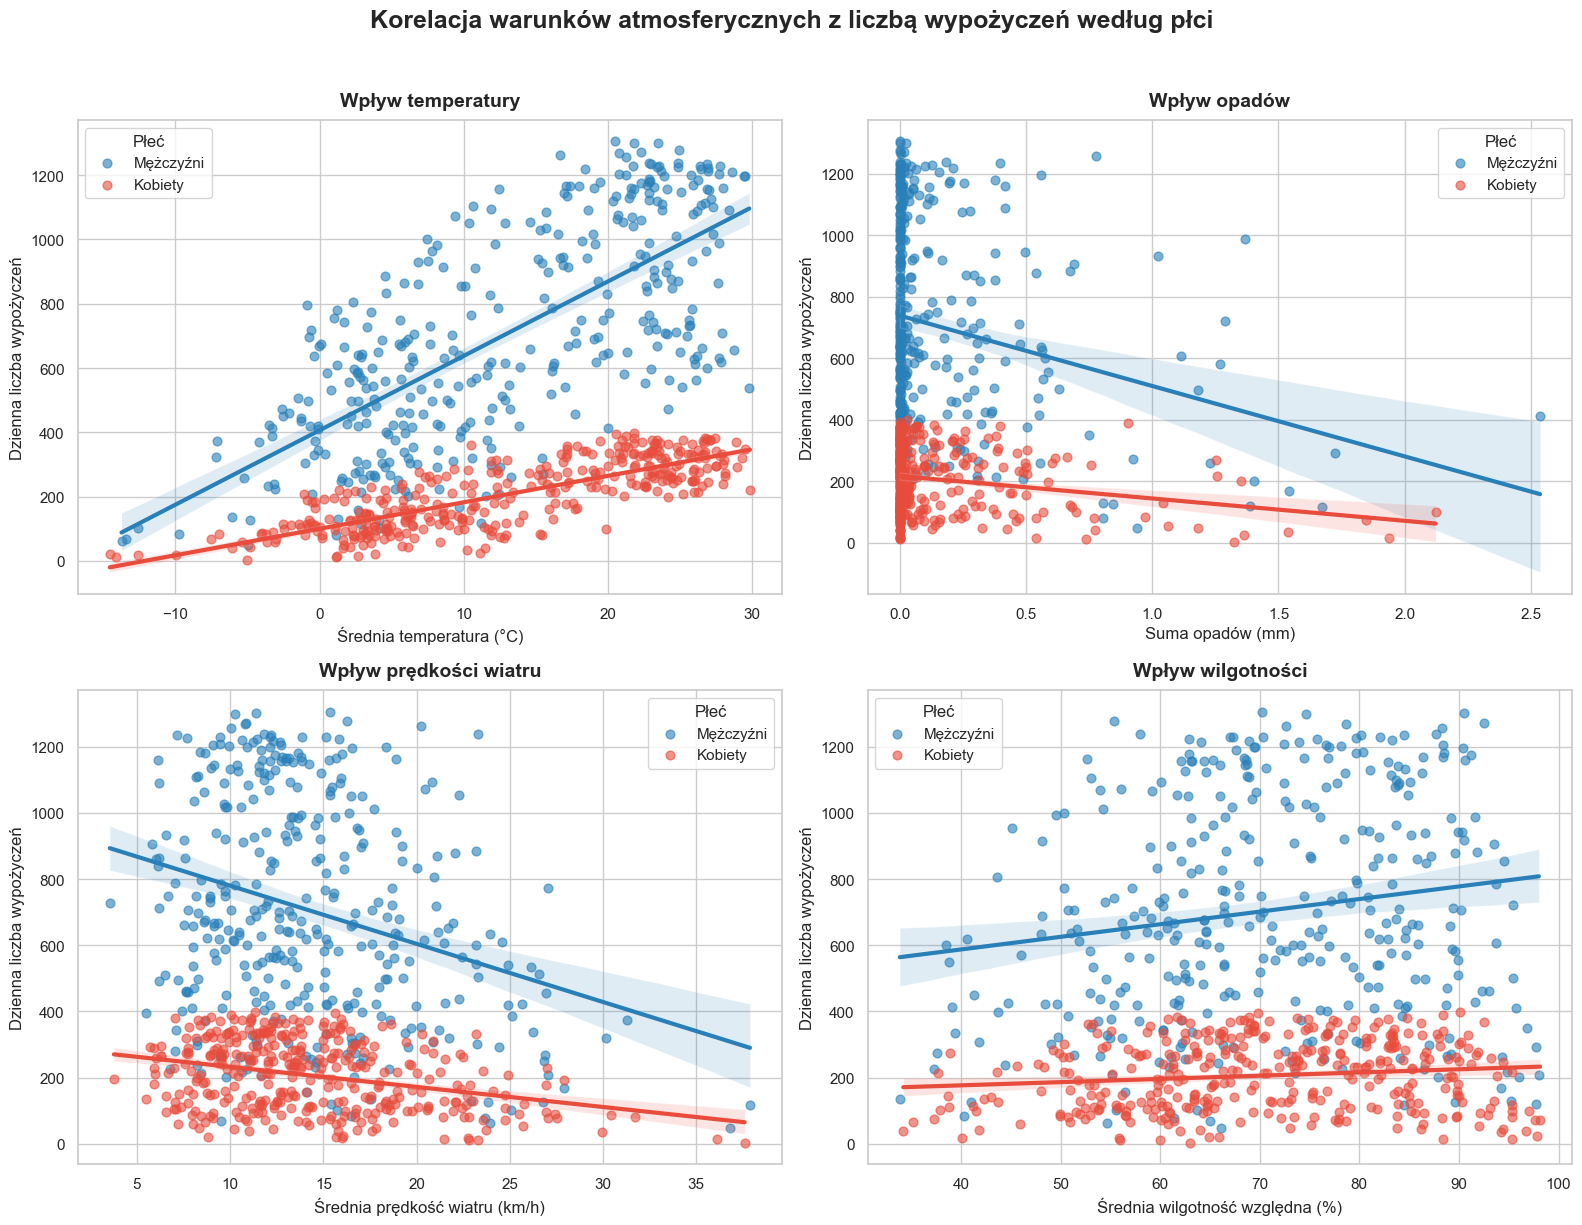

In [42]:
# Korelacja pogody z wypożyczeniami – podział według płci

dzienna_plec = df_pogoda.groupby(['date', 'gender_label']).agg(
    liczba_przejazdow=('starttime', 'count'),
    temperatura=('temperature (°C)', 'mean'),
    opady=('precipitation (mm)', 'mean'),
    wiatr=('wind_speed (km/h)', 'mean'),
    wilgotnosc=('relative_humidity (%)', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Korelacja warunków atmosferycznych z liczbą wypożyczeń według płci',
             fontsize=18, fontweight='bold', y=1.02)

kolory_plci = {'Mężczyźni': '#2980b9', 'Kobiety': '#e74c3c'}


def rysuj_trend_wg_plci(ax, x_col, x_label, title):
    for plec in ['Mężczyźni', 'Kobiety']:
        dane = dzienna_plec[dzienna_plec['gender_label'] == plec]
        sns.regplot(
            data=dane, x=x_col, y='liczba_przejazdow', ax=ax,
            color=kolory_plci[plec], label=plec,
            scatter_kws={'alpha': 0.6, 's': 40},
            line_kws={'linewidth': 3}
        )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Dzienna liczba wypożyczeń', fontsize=12)
    ax.legend(title='Płeć', fontsize=11)


rysuj_trend_wg_plci(axes[0, 0], 'temperatura', 'Średnia temperatura (°C)', 'Wpływ temperatury')
rysuj_trend_wg_plci(axes[0, 1], 'opady', 'Suma opadów (mm)', 'Wpływ opadów')
rysuj_trend_wg_plci(axes[1, 0], 'wiatr', 'Średnia prędkość wiatru (km/h)', 'Wpływ prędkości wiatru')
rysuj_trend_wg_plci(axes[1, 1], 'wilgotnosc', 'Średnia wilgotność względna (%)', 'Wpływ wilgotności')

plt.tight_layout()
plt.savefig('plec', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# Młodzi Mężczyźni (<30 lat) vs Starsze Kobiety (>50 lat)

nazwy_grup_2 = ['Młodzi Mężczyźni (<30 lat)', 'Starsze Kobiety (>50 lat)']

warunki_2 = [
    (df['gender'] == 'Male') & (df['age'] < 30),
    (df['gender'] == 'Female') & (df['age'] > 50)
]

df['grupa_2'] = np.select(warunki_2, nazwy_grup_2, default='Inne')
df_2grupy = df[df['grupa_2'] != 'Inne'].copy()
df_2grupy['grupa_2'] = pd.Categorical(df_2grupy['grupa_2'], categories=nazwy_grup_2, ordered=True)
df_2grupy['data'] = df_2grupy['starttime'].dt.date

# Dane pogodowe dzienne (opady)
pogoda_dz = df_2grupy.groupby('data')['precipitation (mm)'].max().reset_index()
pogoda_dz['czy_deszczowy_dzien'] = pogoda_dz['precipitation (mm)'].apply(
    lambda x: 'Dzień z opadami' if x > 0 else 'Dzień suchy'
)

dzienne_2 = df_2grupy.pivot_table(
    index='data', columns='grupa_2', values='starttime',
    aggfunc='count', fill_value=0,
    observed=False
).reset_index()

df_melt_2 = dzienne_2.melt(id_vars='data', value_name='liczba_przejazdow')
df_dzienne_2 = pd.merge(df_melt_2, pogoda_dz[['data', 'czy_deszczowy_dzien']], on='data')

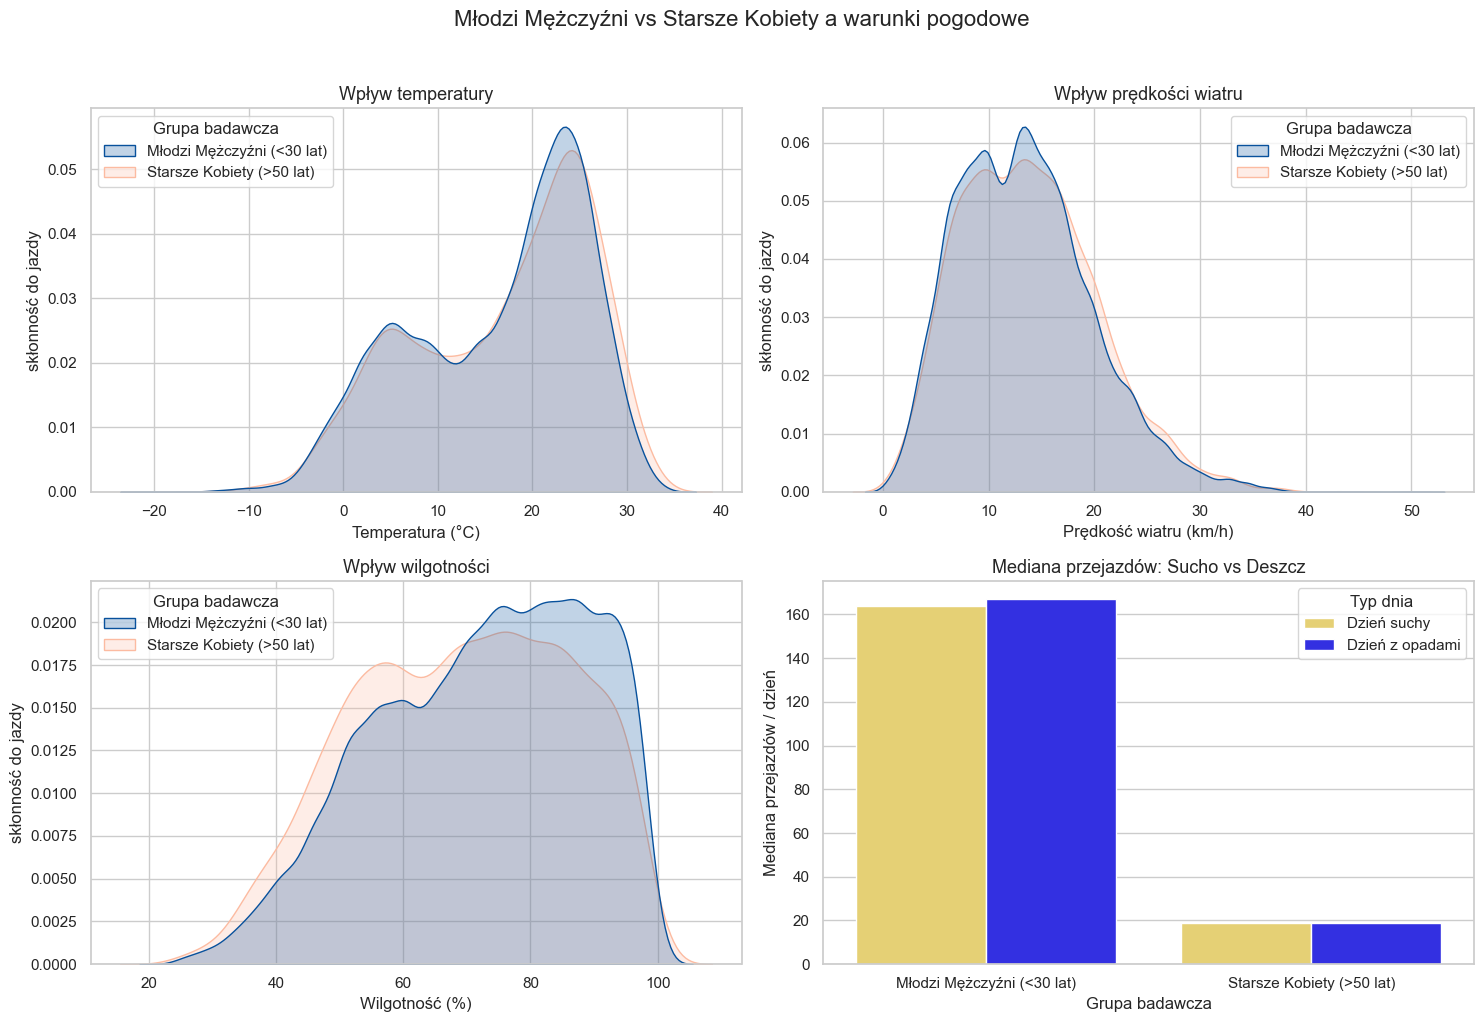

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
paleta_2 = {'Starsze Kobiety (>50 lat)': '#fcbba1', 'Młodzi Mężczyźni (<30 lat)': '#08519c'}

# Temperatura
sns.kdeplot(data=df_2grupy, x='temperature (°C)', hue='grupa_2',
            fill=True, common_norm=False, palette=paleta_2, ax=axes[0, 0])
axes[0, 0].get_legend().set_title('Grupa badawcza')
axes[0, 0].set_title('Wpływ temperatury', fontsize=13)
axes[0, 0].set_xlabel('Temperatura (°C)')
axes[0, 0].set_ylabel('skłonność do jazdy')

# Wiatr
sns.kdeplot(data=df_2grupy, x='wind_speed (km/h)', hue='grupa_2',
            fill=True, common_norm=False, palette=paleta_2, ax=axes[0, 1])
axes[0, 1].get_legend().set_title('Grupa badawcza')
axes[0, 1].set_title('Wpływ prędkości wiatru', fontsize=13)
axes[0, 1].set_xlabel('Prędkość wiatru (km/h)')
axes[0, 1].set_ylabel('skłonność do jazdy')

# Wilgotność
sns.kdeplot(data=df_2grupy, x='relative_humidity (%)', hue='grupa_2',
            fill=True, common_norm=False, palette=paleta_2, ax=axes[1, 0])
axes[1, 0].get_legend().set_title('Grupa badawcza')
axes[1, 0].set_title('Wpływ wilgotności', fontsize=13)
axes[1, 0].set_xlabel('Wilgotność (%)')
axes[1, 0].set_ylabel('skłonność do jazdy')

# Opady
sns.barplot(
    data=df_dzienne_2, x='grupa_2', y='liczba_przejazdow',
    hue='czy_deszczowy_dzien',
    hue_order=['Dzień suchy', 'Dzień z opadami'],
    estimator=np.median, errorbar=None,
    palette=['#F7DC63', '#1612FF'],
    order=nazwy_grup_2, ax=axes[1, 1]
)
axes[1, 1].set_title('Mediana przejazdów: Sucho vs Deszcz', fontsize=13)
axes[1, 1].set_xlabel('Grupa badawcza')
axes[1, 1].set_ylabel('Mediana przejazdów / dzień')
axes[1, 1].legend(title='Typ dnia')

plt.suptitle('Młodzi Mężczyźni vs Starsze Kobiety a warunki pogodowe',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('Stare_baby-Mlode_chlopy', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Porównanie Wiekowe

nazwy_grup_6 = [
    'Młodzi Mężczyźni (<30 lat)',
    'Mężczyźni (30-50 lat)',
    'Starsi Mężczyźni (>50 lat)',
    'Młode Kobiety (<30 lat)',
    'Kobiety (30-50 lat)',
    'Starsze Kobiety (>50 lat)'
]

warunki_6 = [
    (df['gender'] == 'Male') & (df['age'] < 30),
    (df['gender'] == 'Male') & (df['age'] >= 30) & (df['age'] <= 50),
    (df['gender'] == 'Male') & (df['age'] > 50),
    (df['gender'] == 'Female') & (df['age'] < 30),
    (df['gender'] == 'Female') & (df['age'] >= 30) & (df['age'] <= 50),
    (df['gender'] == 'Female') & (df['age'] > 50)
]

df['grupa_6'] = np.select(warunki_6, nazwy_grup_6, default='Inne')
df_6grup = df[df['grupa_6'] != 'Inne'].copy()
df_6grup['grupa_6'] = pd.Categorical(
    df_6grup['grupa_6'], categories=nazwy_grup_6, ordered=True
)
df_6grup['data'] = df_6grup['starttime'].dt.date

# Pogoda dzienna
pogoda_dz6 = df_6grup.groupby('data')['precipitation (mm)'].max().reset_index()
pogoda_dz6['czy_deszczowy_dzien'] = pogoda_dz6['precipitation (mm)'].apply(
    lambda x: 'Dzień z opadami' if x > 0 else 'Dzień suchy'
)

dzienne_6 = df_6grup.pivot_table(
    index='data', columns='grupa_6', values='starttime',
    aggfunc='count', fill_value=0, observed=False
).reset_index()

df_melt_6 = dzienne_6.melt(id_vars='data', value_name='liczba_przejazdow')
df_dzienne_6 = pd.merge(df_melt_6, pogoda_dz6[['data', 'czy_deszczowy_dzien']], on='data')

# Zmiana procentowa
srednia_pogoda = (
    df_dzienne_6
    .groupby(['grupa_6', 'czy_deszczowy_dzien'], observed=False)['liczba_przejazdow']
    .mean()
    .unstack()
)
srednia_pogoda['zmiana_procentowa'] = (
    (srednia_pogoda['Dzień z opadami'] - srednia_pogoda['Dzień suchy'])
    / srednia_pogoda['Dzień suchy'] * 100
)
srednia_pogoda['zmiana_procentowa'] = (
    srednia_pogoda['zmiana_procentowa'].replace([np.inf, -np.inf], np.nan).fillna(0)
)
df_roznica = srednia_pogoda.reset_index()


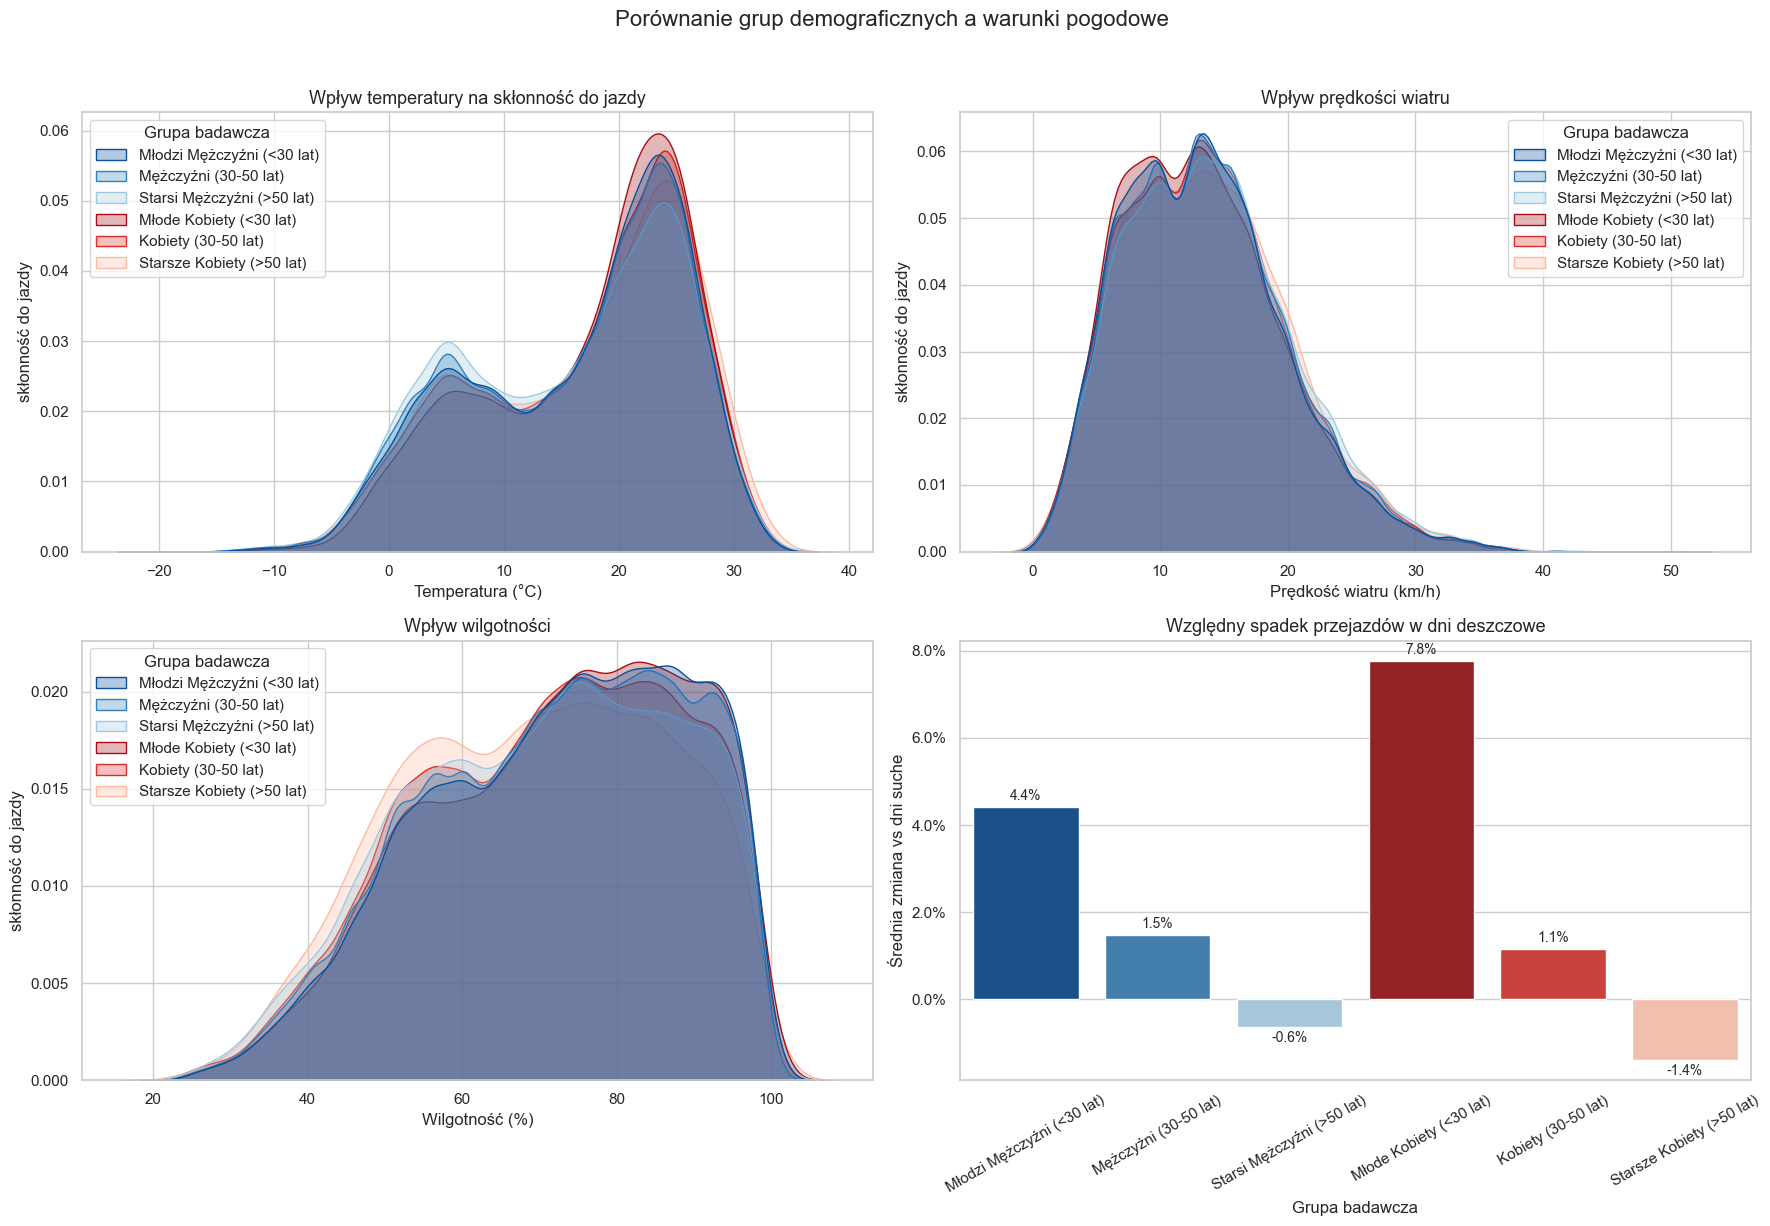

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

paleta_6 = {
    'Młodzi Mężczyźni (<30 lat)': '#08519c',
    'Mężczyźni (30-50 lat)': '#3182bd',
    'Starsi Mężczyźni (>50 lat)': '#9ecae1',
    'Młode Kobiety (<30 lat)': '#a50f15',
    'Kobiety (30-50 lat)': '#de2d26',
    'Starsze Kobiety (>50 lat)': '#fcbba1'
}

# Temperatura
sns.kdeplot(data=df_6grup, x='temperature (°C)', hue='grupa_6',
            fill=True, common_norm=False, palette=paleta_6, alpha=0.3,
            hue_order=nazwy_grup_6, ax=axes[0, 0])
axes[0, 0].get_legend().set_title('Grupa badawcza')
axes[0, 0].set_title('Wpływ temperatury na skłonność do jazdy', fontsize=13)
axes[0, 0].set_xlabel('Temperatura (°C)')
axes[0, 0].set_ylabel('skłonność do jazdy')

# Wiatr
sns.kdeplot(data=df_6grup, x='wind_speed (km/h)', hue='grupa_6',
            fill=True, common_norm=False, palette=paleta_6, alpha=0.3,
            hue_order=nazwy_grup_6, ax=axes[0, 1])
axes[0, 1].get_legend().set_title('Grupa badawcza')
axes[0, 1].set_title('Wpływ prędkości wiatru', fontsize=13)
axes[0, 1].set_xlabel('Prędkość wiatru (km/h)')
axes[0, 1].set_ylabel('skłonność do jazdy')

# Wilgotność
sns.kdeplot(data=df_6grup, x='relative_humidity (%)', hue='grupa_6',
            fill=True, common_norm=False, palette=paleta_6, alpha=0.3,
            hue_order=nazwy_grup_6, ax=axes[1, 0])
axes[1, 0].get_legend().set_title('Grupa badawcza')
axes[1, 0].set_title('Wpływ wilgotności', fontsize=13)
axes[1, 0].set_xlabel('Wilgotność (%)')
axes[1, 0].set_ylabel('skłonność do jazdy')

# Opady – zmiana procentowa
sns.barplot(
    data=df_roznica, x='grupa_6', y='zmiana_procentowa',
    hue='grupa_6',
    legend=False,
    palette=paleta_6, order=nazwy_grup_6, ax=axes[1, 1]
)
axes[1, 1].set_title('Względny spadek przejazdów w dni deszczowe', fontsize=13)
axes[1, 1].set_xlabel('Grupa badawcza')
axes[1, 1].set_ylabel('Średnia zmiana vs dni suche')
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(100))
axes[1, 1].tick_params(axis='x', rotation=30)

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.suptitle('Porównanie grup demograficznych a warunki pogodowe',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('Demografia', dpi=300, bbox_inches='tight')
plt.show()